In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
import write_ic as wic
import os

test_folder = "../tests"

def plot_scaling(x0, y0, b, xmax):
    a = y0 / ((x0) ** b)
    x = np.logspace(np.log10(x0), np.log10(xmax), 100) 
    y = a * (x ** b)
    plt.plot(x,y, ls = '--', lw = 2, color='black')

In [4]:
class Param:
    def __init__(self, **kwargs):
        # Set default values here if needed
        self.values = {}
        self.values.update(kwargs)
        self._update_K_keys()

    def set(self, key, value):
        self.values[key] = value
        if key == "DustSpecies":
            self._update_K_keys()

    def _update_K_keys(self):
        n_dust = int(self.values.get("DustSpecies", 1))
        # Remove any old K_i keys
        for k in list(self.values.keys()):
            if k.startswith("K_"):
                del self.values[k]
        # Add new K_i keys
        for i in range(1, n_dust + 1):
            key = f"K_{i}"
            if key not in self.values:
                self.values[key] = 1000  # Default value

    def write(self, filename):
        with open(filename, "w") as f:
            for key in self.values.keys():
                val = self.values[key]
                f.write(f"{key}: {val:<22}\n")

# DUSTYBOX

In [ ]:
# Write parameter files  

p = Param()
p.set("t_max", 3.0)
p.set("dt_snap", 0.1)
p.set("GAMMA", 1.4)
p.set("BoundaryCondition", 1)
p.set("input_file", f"box_A.inp")
p.set("output_dir", f"output_A/DHD/")
p.set("DustSpecies", 2)
p.set("K_1", 0.5)
p.set("K_2", 1.0)
p.set("DragIntegrator", 1)
p.write(f"{test_folder}/DUSTYBOX/param_A.txt")

p = Param()
p.set("t_max", 0.05)
p.set("dt_snap", 0.001)
p.set("GAMMA", 1.4)
p.set("BoundaryCondition", 1)
p.set("input_file", f"box_B.inp")
p.set("output_dir", f"output_B/DHD/")
p.set("DustSpecies", 2)
p.set("K_1", 100)
p.set("K_2", 500)
p.set("DragIntegrator", 1)
p.set("dt", 0.005)
p.write(f"{test_folder}/DUSTYBOX/param_B.txt")

p = Param()
p.set("t_max", 0.3)
p.set("dt_snap", 0.01)
p.set("GAMMA", 1.4)
p.set("BoundaryCondition", 1)
p.set("input_file", f"box_C.inp")
p.set("output_dir", f"output_C/DHD/")
p.set("DustSpecies", 2)
p.set("K_1", 5)
p.set("K_2", 100)
p.set("DragIntegrator", 1)
p.set("dt", 0.05)
p.write(f"{test_folder}/DUSTYBOX/param_C.txt")

In [83]:
wic.write_box_A(256, test_folder)
wic.write_box_B(256, test_folder)
wic.write_box_C(256, test_folder)

In [ ]:
# Parameters for the analytical solution 
vCOM = np.array([1.16666666666667, 1.16666666666667, 0.63963963963963])
lambda_1 = np.array([ -0.63397459621556, -141.742430504416, -0.52370200744224])
lambda_2 = np.array([ -2.36602540378444, -1058.25756949558, -105.976297992557])
cg_1 = np.array([ -0.22767090063074, -0.35610569612832, -0.06458203330249])
cg_2 = np.array([ 0.06100423396407, 0.18943902946166, 0.42494239366285])
cd_1_1 = np.array([ 0.84967936855889, 0.85310244713865, 1.36237475791577])
cd_1_2 = np.array([ -0.01634603522555, -0.01976911380532, -0.00201439755542])
cd_2_1 = np.array([ -0.62200846792815, -0.49699675101033, -0.13559165545855])
cd_2_2 = np.array([ -0.04465819873852, -0.16966991565634, -0.00404798418109])

C:\Users\giovt\AppData\Local\Temp\ipykernel_84048\2379342162.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


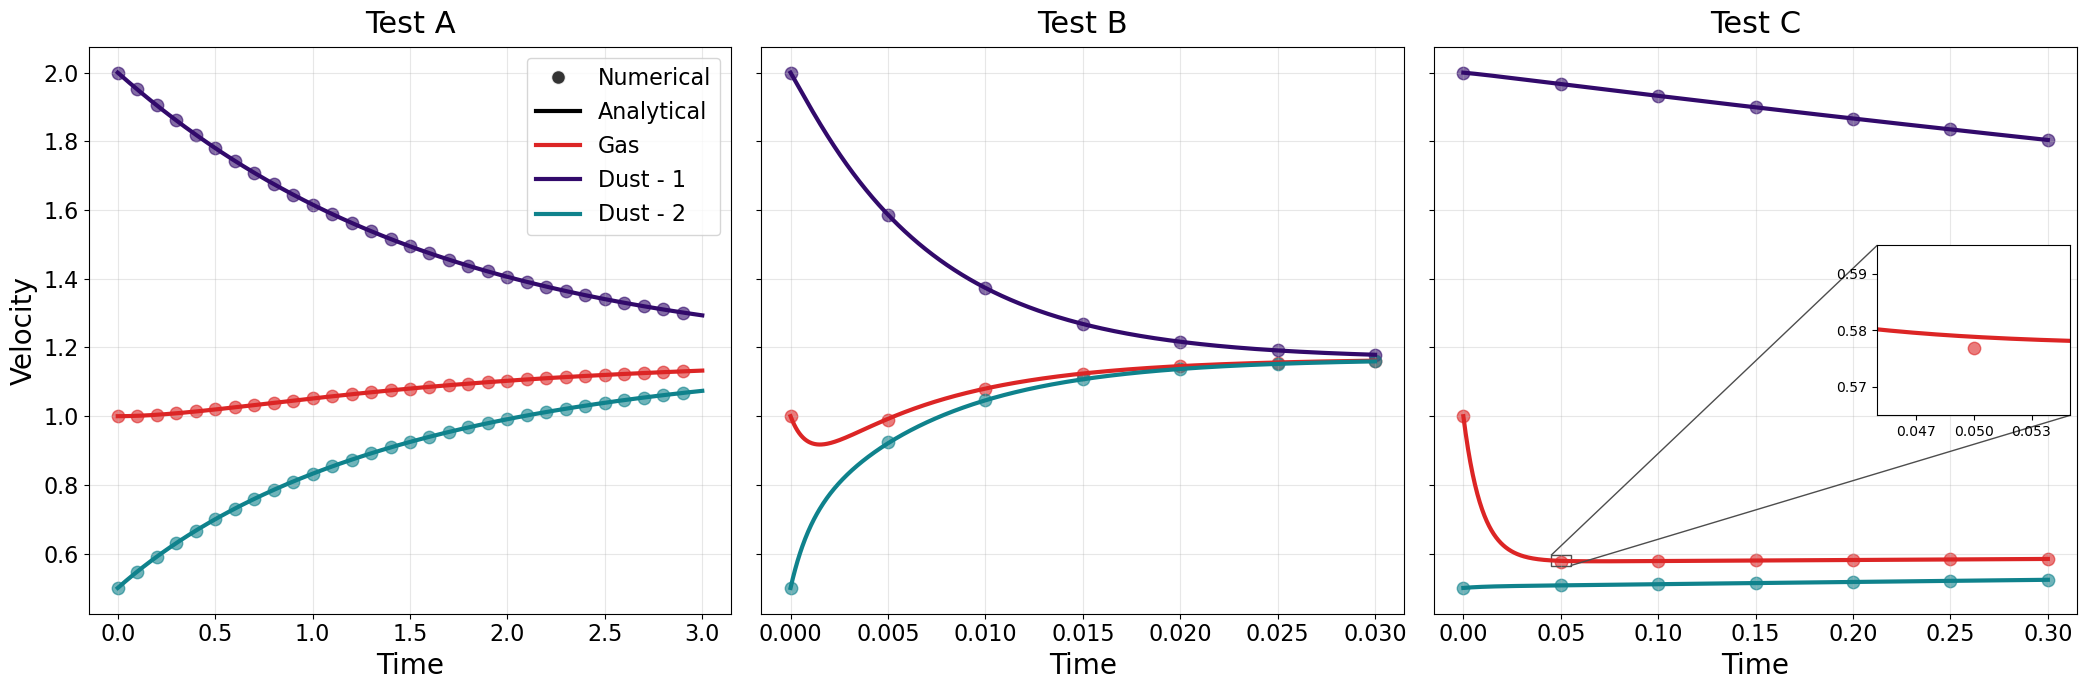

In [84]:
fig, axs = plt.subplots(1,3, figsize=(21,7))
tmax = [3,0.03,0.3]
folder = ["output_A", "output_B", "output_C"]
titles = ["Test A", "Test B", "Test C"]
imax = [30, 7, 7]
for j in range(0,3):
    for i in range(0,imax[j]):
        data = np.loadtxt("%s/DUSTYBOX/%s/DHD/%d.txt"%(test_folder,folder[j],i))
        axs[j].scatter(data[0,-1], np.mean(data[:,1]), color='#DC2525', marker='o', alpha=0.6, s=80)
        axs[j].scatter(data[0,-1], np.mean(data[:,4]), color='#320A6B', marker='o', alpha=0.6, s=80)
        axs[j].scatter(data[0,-1], np.mean(data[:,6]), color='#0F828C', marker='o', alpha=0.6, s=80)

    axs[j].grid(alpha=0.3)


    t = np.linspace(0,tmax[j],1000)
    itest = j
    v_g = vCOM[itest] + cg_1[itest] * np.exp(lambda_1[itest]*t) + cg_2[itest]*np.exp(lambda_2[itest]*t)
    v_d_1 = vCOM[itest] + cd_1_1[itest] * np.exp(lambda_1[itest]*t) + cd_1_2[itest]*np.exp(lambda_2[itest]*t)
    v_d_2 = vCOM[itest] + cd_2_1[itest] * np.exp(lambda_1[itest]*t) + cd_2_2[itest]*np.exp(lambda_2[itest]*t)

    axs[j].plot(t, v_g, color='#DC2525', label='Gas', lw=3)
    axs[j].plot(t, v_d_1, color='#320A6B', label='Dust - 1', lw=3)
    axs[j].plot(t, v_d_2, color='#0F828C', label='Dust - 2', lw=3)
    axs[j].set_title(titles[j], fontsize=22, pad=10)

    
    axs[j].set_xlabel("Time", fontsize=20)
    axs[j].tick_params(labelsize=16)

axs[0].set_ylabel("Velocity", fontsize=20)
axs[1].axes.yaxis.set_ticklabels([])
axs[2].axes.yaxis.set_ticklabels([])
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Numerical', markerfacecolor='black',alpha=0.8, markersize=10),
                   Line2D([0], [0], color='black', label='Analytical', lw=3),
                   Line2D([0], [0], color='#DC2525', lw=3, label='Gas'),
                   Line2D([0], [0], color='#320A6B', lw=3, label='Dust - 1'),
                   Line2D([0], [0], color='#0F828C', lw=3, label='Dust - 2')]

# Create the figure
axs[0].legend(handles=legend_elements,fontsize=16)


axins = inset_axes(axs[2], width="30%", height="30%", loc="center right")
for i in range(0,imax[2]):
    data = np.loadtxt("%s/DUSTYBOX/output_C/DHD/%d.txt"%(test_folder,i))
    axins.scatter(data[0,-1], np.mean(data[:,1]), color='#DC2525', marker='o', alpha=0.6, s=80)
axins.plot(t, v_g, color='#DC2525', label='Gas', lw=3)
axins.set_xlim(0.045, 0.055)
axins.set_ylim(0.565, 0.595)
axins.set_xticks([0.047, 0.05, 0.053])
mark_inset(axs[2], axins, loc1=2, loc2=4, fc="none", ec="0.3")

fig.tight_layout()

#plt.savefig("DUSTYBOX.png", dpi=600, bbox_inches='tight')

# DUSTYWAVE

In [114]:
def wave(x, f0, df_real, df_im):
    return f0 + 1e-4 * (df_real * np.cos(2*np.pi*x) - df_im * np.sin(2*np.pi*x))

def fit_wave(data):
    x = np.linspace(0,1,data.shape[0])
    popt, _ = curve_fit(wave, x, data, maxfev = int(1e5))
    return popt[1] / popt[0]


In [115]:
# Write parameter files  

p = Param()
p.set("t_max", 2.0)
p.set("dt_snap", 0.1)
p.set("GAMMA", 1.00001)
p.set("BoundaryCondition", 1)
p.set("input_file", f"wave_A.inp")
p.set("output_dir", f"output_A/DHD/")
p.set("DustSpecies", 1)
p.set("K_1", 5.6)
p.set("DragIntegrator", 1)
p.write(f"{test_folder}/DUSTYWAVE/param_A.txt")

p = Param()
p.set("t_max", 2.0)
p.set("dt_snap", 0.1)
p.set("GAMMA", 1.00001)
p.set("BoundaryCondition", 1)
p.set("input_file", f"wave_B.inp")
p.set("output_dir", f"output_B/DHD/")
p.set("DustSpecies", 4)
p.set("K_1", 1.0)
p.set("K_2", 1.083038)
p.set("K_3", 0.789959)
p.set("K_4", 0.5)
p.set("DragIntegrator", 1)
p.write(f"{test_folder}/DUSTYWAVE/param_B.txt")



In [116]:
wic.write_wave_A(256, test_folder)
wic.write_wave_B(256, test_folder)

[0.00000000e+00 1.17178532e-03 2.34357085e-03 ... 1.99800776e+00
 1.99917963e+00 2.00000000e+00]
[0.00000000e+00 1.17177114e-03 2.34354240e-03 ... 1.99796539e+00
 1.99913725e+00 2.00000000e+00]


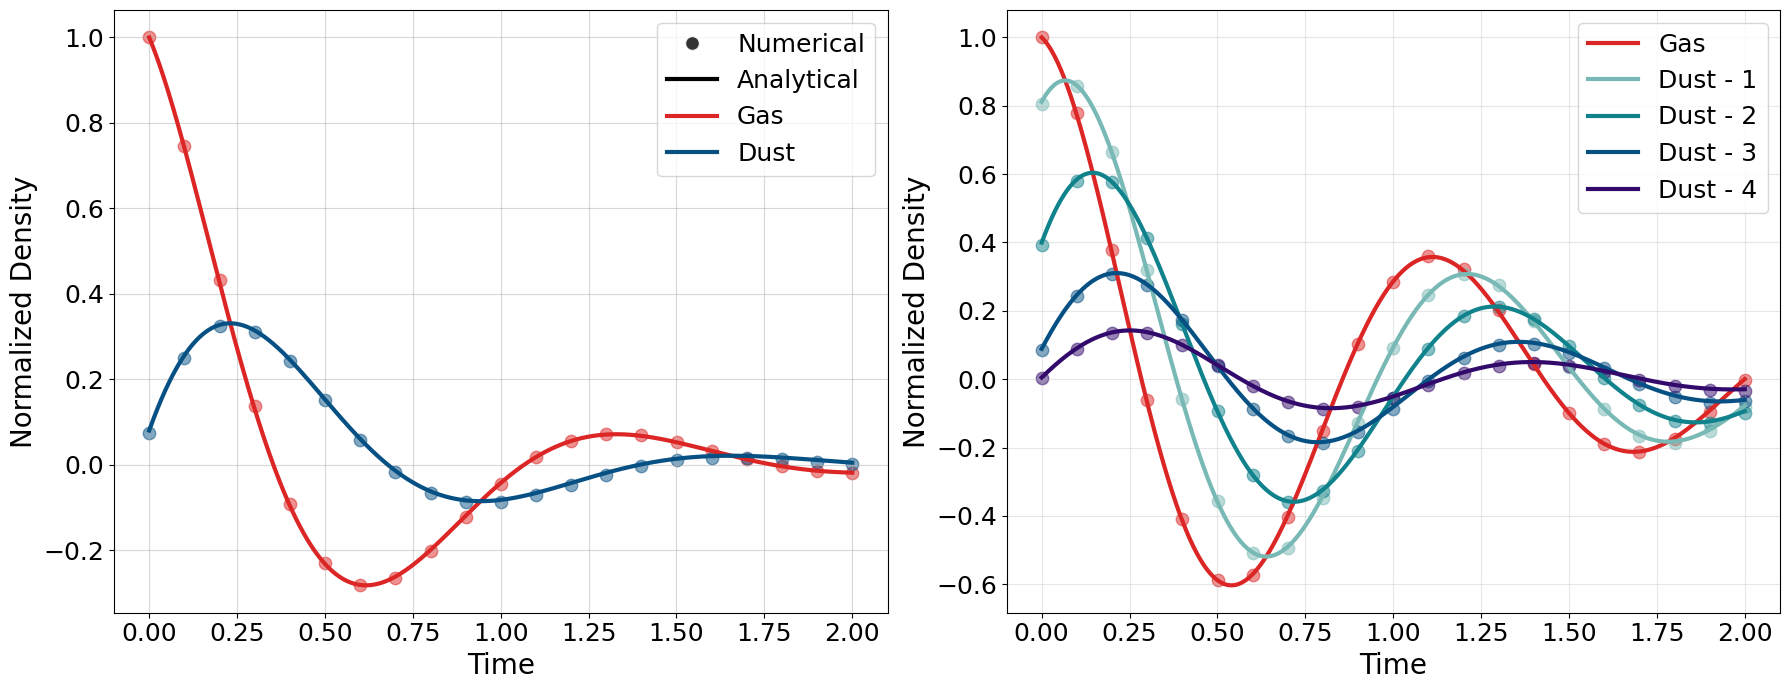

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(18,7))

data = np.loadtxt("solutions/wave_damping_A.txt")
print(data[:,0])
axs[0].plot(data[:,0], data[:,1], label='Gas', lw=3, color='#DC2525')
axs[0].plot(data[:,0],data[:,2], label = 'Dust', lw=3, color='#065084')

for i in range(0,21):
    data = np.loadtxt("%s/DUSTYWAVE/output_A/DHD/%d.txt"%(test_folder,i))
    axs[0].scatter(data[0,-1], fit_wave(data[:,0]), color='#DC2525', alpha=0.5, s=80)
    axs[0].scatter(data[0,-1], fit_wave(data[:,3]), color='#065084', alpha=0.5, s=80)

axs[0].legend(fontsize=14)
axs[0].set_ylabel("Normalized Density", fontsize=20)
axs[0].set_xlabel("Time", fontsize=20)
axs[0].grid(alpha=0.5)



data = np.loadtxt("solutions/wave_damping_B.txt")
print(data[:,0])
axs[1].plot(data[:,0], data[:,1], label='Gas', lw=3, color='#DC2525')
axs[1].plot(data[:,0],data[:,2], label = 'Dust - 1', lw=3, color='#78B9B5')
axs[1].plot(data[:,0],data[:,3], label = 'Dust - 2', lw=3, color='#0F828C')
axs[1].plot(data[:,0],data[:,4], label = 'Dust - 3', lw=3, color='#065084')
axs[1].plot(data[:,0],data[:,5], label = 'Dust - 4', lw=3, color='#320A6B')

for i in range(0,21):
    data = np.loadtxt("%s/DUSTYWAVE/output_B/DHD/%d.txt"%(test_folder,i))
    axs[1].scatter(data[0,-1], fit_wave(data[:,0]), color='#DC2525', alpha=0.5, s=80)
    axs[1].scatter(data[0,-1], fit_wave(data[:,3]), color='#78B9B5', alpha=0.5, s=80)
    axs[1].scatter(data[0,-1], fit_wave(data[:,5]), color='#0F828C', alpha=0.5, s=80)
    axs[1].scatter(data[0,-1], fit_wave(data[:,7]), color='#065084', alpha=0.5, s=80)
    axs[1].scatter(data[0,-1], fit_wave(data[:,9]), color='#320A6B', alpha=0.5, s=80)

axs[1].legend(fontsize=14)
axs[1].set_ylabel("Normalized Density", fontsize=20)
axs[1].set_xlabel("Time", fontsize=20)
axs[1].grid(alpha=0.3)
for ax in axs:
    ax.tick_params(labelsize=18)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Numerical', markerfacecolor='black',alpha=0.8, markersize=10),
                   Line2D([0], [0], color='black', label='Analytical', lw=3),
                   Line2D([0], [0], color='#DC2525', lw=3, label="Gas"),
                   Line2D([0], [0], color='#065084', lw=3, label= "Dust")]

# Create the figure
axs[0].legend(handles=legend_elements,fontsize=18)

legend_elements = [Line2D([0], [0], color='#DC2525', lw=3, label="Gas"),
                   Line2D([0], [0], color='#78B9B5', lw=3, label= "Dust - 1"),
                   Line2D([0], [0], color='#0F828C', lw=3, label= "Dust - 2"),
                   Line2D([0], [0], color='#065084', lw=3, label= "Dust - 3"),
                   Line2D([0], [0], color='#320A6B', lw=3, label= "Dust - 4")]

# Create the figure
axs[1].legend(handles=legend_elements,fontsize=18)

fig.tight_layout()

#plt.savefig("DUSTYWAVE.png", dpi=600, bbox_inches='tight')

# DUSTYSHOCK

In [123]:
# Write parameter files  

p = Param()
p.set("t_max", 400)
p.set("dt_snap", 10)
p.set("GAMMA", 1.00001)
p.set("BoundaryCondition", 0)
p.set("input_file", f"shock_B.inp")
p.set("output_dir", f"output_B/DHD/")
p.set("DustSpecies", 3)
p.set("K_1", 1.0)
p.set("K_2", 3.0)
p.set("K_3", 5.0)
p.set("DragIntegrator", 1)
p.set("L", 40)
p.set("RiemannSolver", 0)
p.write(f"{test_folder}/DUSTYSHOCK/param_B.txt")



In [128]:
wic.write_shock_B(400, test_folder)

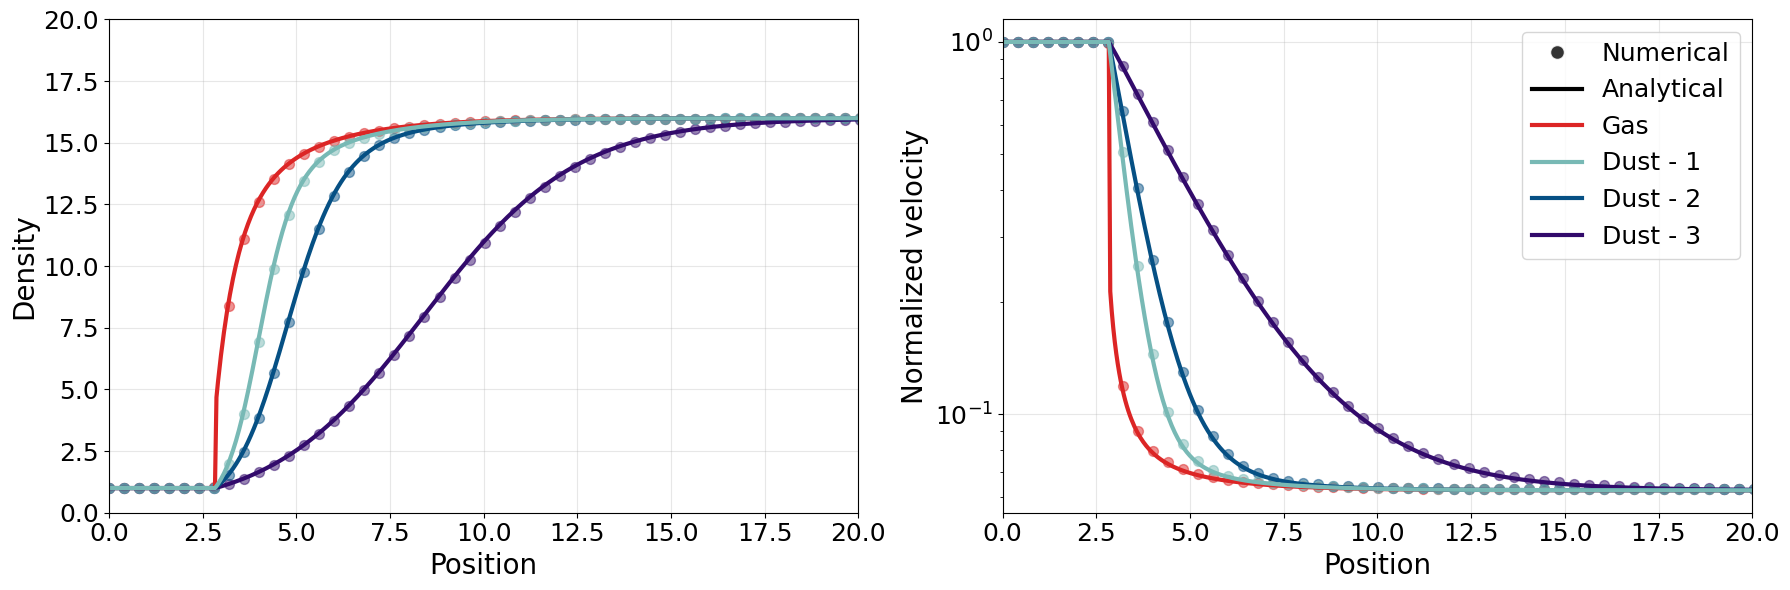

In [8]:
fig, axs = plt.subplots(1,2, figsize=(18,6))
N = 400
data = np.loadtxt(f"{test_folder}/DUSTYSHOCK/output_B/DHD/40.txt")

x = np.linspace(0,40,N)
N_plot = 4
axs[0].scatter(x[::N_plot], data[::N_plot,0], color='#DC2525', alpha=0.5, s=50)
axs[0].scatter(x[::N_plot], data[::N_plot,3], color='#320A6B', alpha=0.5, s=50)
axs[0].scatter(x[::N_plot], data[::N_plot,5], color='#065084', alpha=0.5, s=50)
axs[0].scatter(x[::N_plot], data[::N_plot,7], color='#78B9B5', alpha=0.5, s=50)

axs[1].scatter(x[::N_plot], data[::N_plot,1] / 2, label='Gas', color='#DC2525', alpha=0.5, s=50)
axs[1].scatter(x[::N_plot], data[::N_plot,4] / 2, label='Dust - 1', color='#320A6B', alpha=0.5, s=50)
axs[1].scatter(x[::N_plot], data[::N_plot,6] / 2, label='Dust - 2', color='#065084', alpha=0.5, s=50)
axs[1].scatter(x[::N_plot], data[::N_plot,8] / 2, label='Dust - 3', color='#78B9B5', alpha=0.5, s=50)


data = np.loadtxt("solutions/shock_steady_state.txt")
data[:,0] -= 0.15
axs[0].plot(data[:,0], data[:,1], color='#DC2525', lw=3)
axs[0].plot(data[:,0], data[:,2], color='#320A6B', lw=3)
axs[0].plot(data[:,0], data[:,3], color='#065084', lw=3)
axs[0].plot(data[:,0], data[:,4], color='#78B9B5', lw=3)


axs[1].plot(data[:,0], data[:,5], color='#DC2525', lw=3)
axs[1].plot(data[:,0], data[:,6], color='#320A6B', lw=3)
axs[1].plot(data[:,0], data[:,7], color='#065084', lw=3)
axs[1].plot(data[:,0], data[:,8], color='#78B9B5', lw=3)

axs[1].set_yscale('log')
axs[0].set_xlim(0,20)
axs[0].set_ylim(0,20)
axs[1].set_xlim(0,20)
axs[0].set_ylabel("Density", fontsize=20)
axs[1].set_ylabel("Normalized velocity", fontsize=20)
axs[1].legend(fontsize=16)
for ax in axs:
    ax.grid(alpha=0.3)
    ax.set_xlabel("Position", fontsize=20)
    ax.tick_params(labelsize=18)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='Numerical', markerfacecolor='black',alpha=0.8, markersize=10),
                   Line2D([0], [0], color='black', label='Analytical', lw=3),
                   Line2D([0], [0], color='#DC2525', lw=3, label="Gas"),
                   Line2D([0], [0], color='#78B9B5', lw=3, label= "Dust - 1"),
                   Line2D([0], [0], color='#065084', lw=3, label= "Dust - 2"),
                   Line2D([0], [0], color='#320A6B', lw=3, label= "Dust - 3")]

# Create the figure
axs[1].legend(handles=legend_elements,fontsize=18)

fig.tight_layout()
#fig.savefig("DUSTYSHOCK.png", dpi=600, bbox_inches='tight')

# External Force

In [3]:
# Write parameter files  

p = Param()
p.set("t_max", 10)
p.set("dt_snap", 0.1)
p.set("GAMMA", 1.00001)
p.set("BoundaryCondition", 1)
p.set("input_file", f"ext_force.inp")
p.set("output_dir", f"output/DHD/")
p.set("DustSpecies", 2)
p.set("K_1", 0.1)
p.set("K_2", 0.075)
p.set("DragIntegrator", 1)
p.set("g0", 1.0)
p.write(f"{test_folder}/EXT_FORCE/param.txt")



In [4]:
wic.write_ext_force(100, test_folder)

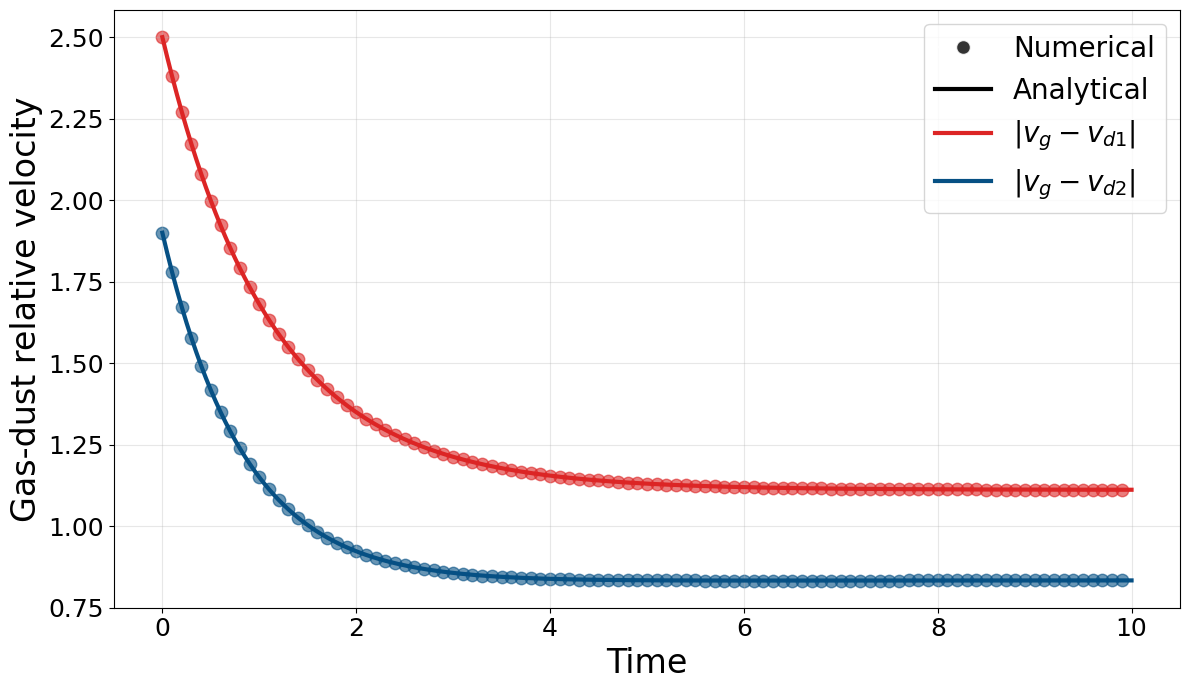

In [8]:
plt.figure(figsize=(12,7))
def get_sol(t):
    C = np.matrix([[0.833333, 0.145014, 0.059615, 1.79537],
                   [0.083333, -0.116011, 0.029808, 0.096204],
                   [0.083333, -0.029003, -0.089423, 0.068426]])
    lambda1 = -1.125 
    lambda2 = -0.8
    v = np.array([t, np.exp(lambda1*t), np.exp(lambda2*t),1])
    sol = np.array(C@v)[0]
    return sol 

t = np.linspace(0,10,1000)
vg = np.zeros_like(t)
vd1 = np.zeros_like(t)
vd2 = np.zeros_like(t)
i = 0
for it in t:
    sol = get_sol(it)
    vg[i] = sol[0]
    vd1[i] = sol[1] / 0.1
    vd2[i] = sol[2] / 0.1
    i += 1

plt.plot(t, np.abs(vg - vd1), lw=3, label = r"$|v_g - v_{d1}|$", color='#065084')
plt.plot(t, np.abs(vg - vd2), lw=3, label = r"$|v_g - v_{d2}|$", color='#DC2525')
plt.grid(alpha=0.3)

for i in range(0,100):
    data = np.loadtxt(f"{test_folder}/EXT_FORCE/output/DHD/{i}.txt")
    plt.scatter(data[0,-1], np.abs(np.mean(data[:,1]) - np.mean(data[:,4])), color='#065084', marker='o', alpha=0.6, s=80)
    plt.scatter(data[0,-1], np.abs(np.mean(data[:,1]) - np.mean(data[:,6])), color='#DC2525', marker='o', alpha=0.6, s=80)

plt.ylabel("Gas-dust relative velocity", fontsize=24)
plt.xlabel("Time", fontsize=24)
plt.tick_params(labelsize=18)
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Numerical', markerfacecolor='black',alpha=0.8, markersize=10),
                   Line2D([0], [0], color='black', label='Analytical', lw=3),
                   Line2D([0], [0], color='#DC2525', lw=3, label=r"$|v_g - v_{d1}|$"),
                   Line2D([0], [0], color='#065084', lw=3, label= r"$|v_g - v_{d2}|$")]

# Create the figure
plt.legend(handles=legend_elements,fontsize=20)

plt.tight_layout()
#plt.savefig("EXT_FORCE.png", dpi=600, bbox_inches='tight')




# Steady-state gas dust drift

In [ ]:
# Write parameter files  

p = Param()
p.set("t_max", 20)
p.set("dt_snap", 0.1)
p.set("GAMMA", 1.00001)
p.set("BoundaryCondition", 1)
p.set("input_file", f"linA.inp")
p.set("output_dir", f"output/DHD/")
p.set("DustSpecies", 1)
p.set("K_1", 30)
p.set("DragIntegrator", 1)
p.set("N_dims", 2)
p.set("N_ghost", 2)
p.set("ghost_in_input", 1)
p.set("sound_speed", 0.05)
p.set("apply_reconstruction", 0)
p.set("Omega0", 1)
p.set("q", 1.5)

p.write(f"{test_folder}/STEADY_STATE_DRIFT/param.txt")



In [6]:
wic.write_steady_state_drift(256, test_folder)

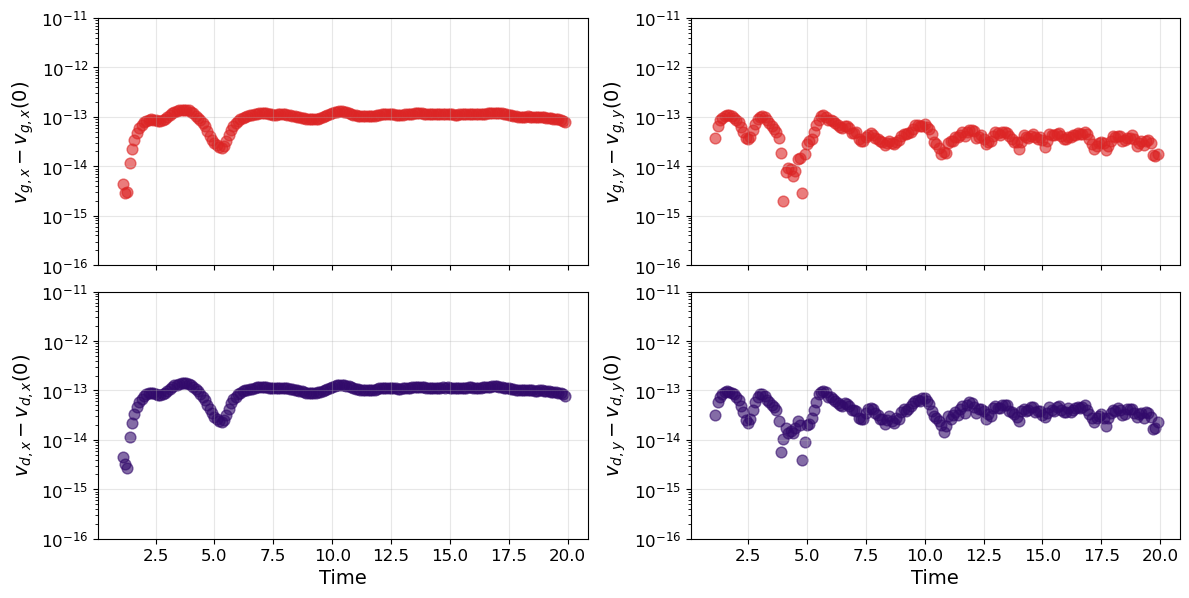

In [ ]:
t = np.arange(10,200,1).astype("int")
fig, axs = plt.subplots(2,2,figsize=(12,6))

data = np.loadtxt(f"{test_folder}/STEADY_STATE_DRIFT/output/DHD/10.txt")
vgx0 = np.mean(data[:,1])
vgy0 = np.mean(data[:,2])
vdx0 = np.mean(data[:,5])
vdy0 = np.mean(data[:,6])

for it in t:
    data = np.loadtxt(f"{test_folder}/STEADY_STATE_DRIFT/output/DHD/{it}.txt")
    axs[0,0].scatter(it/10, np.abs(np.mean(data[:,1]) - vgx0), color='#DC2525', marker='o', alpha=0.6, s=60)
    axs[0,1].scatter(it/10, np.abs(np.mean(data[:,2]) - vgy0), color='#DC2525', marker='o', alpha=0.6, s=60)
    axs[1,0].scatter(it/10, np.abs(np.mean(data[:,5]) - vdx0), color='#320A6B', marker='o', alpha=0.6, s=60)
    axs[1,1].scatter(it/10, np.abs(np.mean(data[:,6]) - vdy0), color='#320A6B', marker='o', alpha=0.6, s=60)

axs[0,0].set_xticklabels([])
axs[0,1].set_xticklabels([])
axs[1,0].set_xlabel("Time", fontsize=14)
axs[1,1].set_xlabel("Time", fontsize=14)
axs[0,0].set_ylabel(r"$v_{g,x} - v_{g,x}(0)$", fontsize=14)
axs[0,1].set_ylabel(r"$v_{g,y} - v_{g,y}(0)$", fontsize=14)
axs[1,0].set_ylabel(r"$v_{d,x} - v_{d,x}(0)$", fontsize=14)
axs[1,1].set_ylabel(r"$v_{d,y} - v_{d,y}(0)$", fontsize=14)
for ax in axs.flatten():
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=12)
    ax.set_yscale('log')
    ax.set_ylim(1e-16,1e-11)
fig.tight_layout()
#fig.savefig(f"{test_folder}/STEADY_STATE_DRIFT.png", dpi=600, bbox_inches='tight')